In [1]:
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
s3 = boto3.client('s3')

bucket_name = 'cmse492-chaud114-nyc311-704788404995-us-east-1-an'       # replace with your bucket name
file_name = 'modeling/resolution_time_modeling.csv'  # include folder path if needed

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')

df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,MANHATTAN,Consumer Complaint,10032.0,4,16,24,30
1,DCWP,QUEENS,Consumer Complaint,11106.0,4,20,24,0
2,DCWP,MANHATTAN,Consumer Complaint,10019.0,4,11,24,30
3,DCWP,STATEN ISLAND,Consumer Complaint,10312.0,4,20,24,19
4,DCWP,BROOKLYN,Consumer Complaint,11212.0,4,8,24,36


In [3]:
# Quick data check — confirm the shape, column names, and target variable
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']

Missing values:
agency                          0
borough                         0
problem                         0
incident_zip                 1765
day_of_week                     0
hour_of_day                     0
same_day_complaint_volume       0
days_to_close                   0
dtype: int64

Data types:
agency                        object
borough                       object
problem                       object
incident_zip                 float64
day_of_week                    int64
hour_of_day                    int64
same_day_complaint_volume      int64
days_to_close                  int64
dtype: object


Features: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
Target: days_to_close

Target distribution stats:
count    173851.000000
mean          2.061656
std           5.120339
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          49.000000
Name: days_to_close, dtype: float64


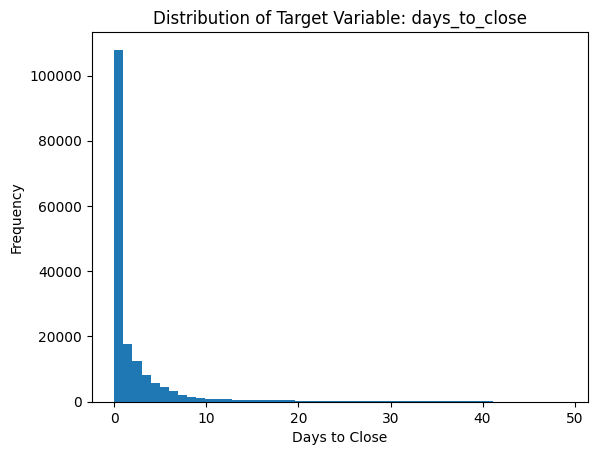

In [4]:
# Define feature columns and target column
feature_cols = ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
target_col   = 'days_to_close'

X = df[feature_cols]
y = df[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")

# Quick check of target distribution
print("\nTarget distribution stats:")
print(y.describe())

import matplotlib.pyplot as plt
plt.hist(y, bins=50)
plt.xlabel('Days to Close')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable: days_to_close')
plt.show()

In [5]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139080 rows
Test set:      34771 rows

Class balance in training set:
days_to_close
0     0.621
1     0.102
2     0.071
3     0.047
4     0.034
5     0.026
6     0.018
7     0.011
8     0.008
9     0.007
10    0.005
11    0.004
12    0.004
13    0.004
14    0.003
15    0.003
16    0.003
17    0.002
19    0.002
18    0.002
20    0.002
21    0.002
22    0.002
23    0.002
26    0.001
30    0.001
25    0.001
24    0.001
27    0.001
29    0.001
28    0.001
32    0.001
31    0.001
33    0.001
35    0.001
34    0.001
36    0.001
40    0.000
38    0.000
37    0.000
41    0.000
39    0.000
42    0.000
45    0.000
43    0.000
44    0.000
46    0.000
48    0.000
47    0.000
49    0.000
Name: proportion, dtype: float64

Class balance in test set:
days_to_close
0     0.621
1     0.102
2     0.071
3     0.047
4     0.034
5     0.026
6     0.018
7     0.011
8     0.008
9     0.007
10    0.005
11    0.004
12    0.004
13    0.004
14    0.003
15    0.003
16    0.003
17    0.003
19    0.00

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns (optional but often helpful for models like Logistic Regression)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or 'median' or 'most_frequent'
X_train_enc = imputer.fit_transform(X_train_enc)
X_test_enc = imputer.fit_transform(X_test_enc)

# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (3): ['agency', 'borough', 'problem']
Numeric columns     (4): ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



Encoded feature matrix shape: (139080, 163)
Total features after encoding: 163

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


In [19]:
# Import the logistic regression model
from sklearn.linear_model import LinearRegression

# Train the logistic regression baseline (adjust the model type and parameters as needed for your specific task)
model = LinearRegression()
model.fit(X_train_enc, y_train)

print("Model trained successfully.")

Model trained successfully.


In [20]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model coefficients (top 10 by magnitude):
                               feature  coefficient
             same_day_complaint_volume    -4.795958
                            agency_DEP    -4.795958
                            agency_DHS    -4.795958
    problem_Unsanitary Animal Facility    -4.795958
problem_Unsanitary Animal Pvt Property    -4.795958
   problem_Unsanitary Pigeon Condition    -4.795958
                problem_Uprooted Stump    -4.795958
           problem_Urinating in Public    -4.795958
            problem_Vendor Enforcement    -4.795958
       problem_Violation of Park Rules    -4.795958

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
)

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets